In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from scipy import stats

df = pd.read_csv("data.csv", sep=';')

In [22]:
print(df.dtypes)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nNumeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)

Gender                                    object
Age                                      float64
Academic Pressure                        float64
Study Satisfaction                       float64
Sleep Duration                            object
Dietary Habits                            object
Have you ever had suicidal thoughts ?     object
Study Hours                                int64
Financial Stress                         float64
Family History of Mental Illness          object
dtype: object

Numeric Columns: ['Age', 'Academic Pressure', 'Study Satisfaction', 'Study Hours', 'Financial Stress']
Categorical Columns: ['Gender', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


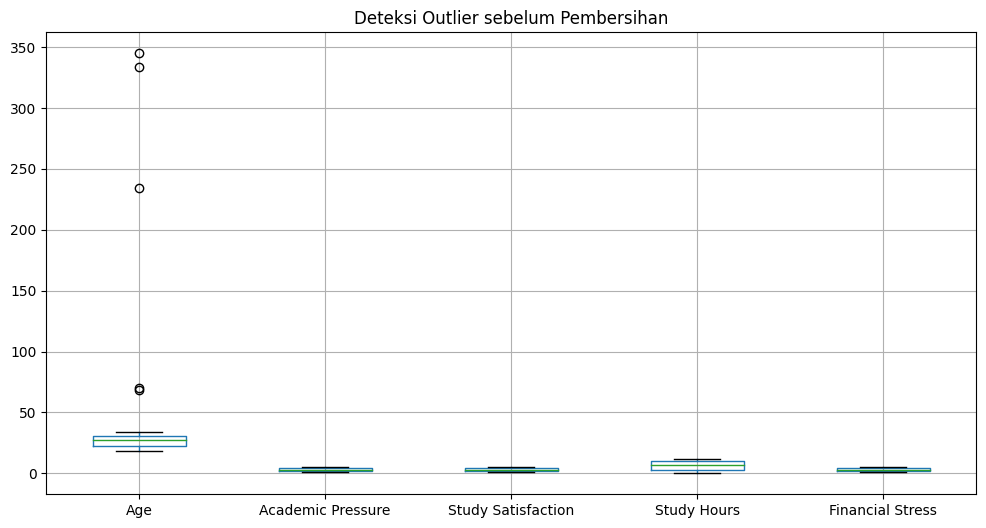

In [23]:
plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot()
plt.title("Deteksi Outlier sebelum Pembersihan")
plt.savefig('boxplot_outliers.png')
plt.show()

In [24]:
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

 Handling Outliers 
Jumlah baris setelah menghapus outlier: 485


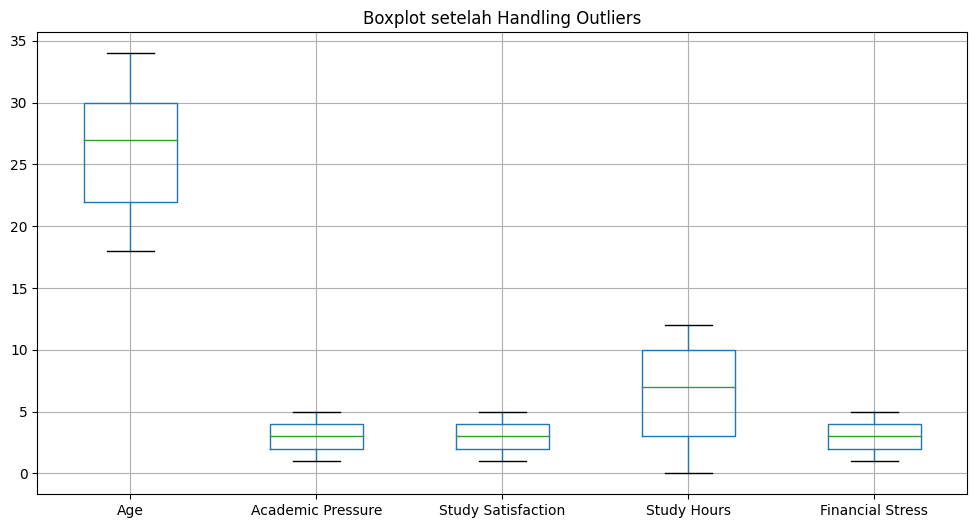

In [25]:
print(" Handling Outliers ")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    
print(f"Jumlah baris setelah menghapus outlier: {len(df)}")

plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot()
plt.title("Boxplot setelah Handling Outliers")
plt.savefig('boxplot_cleaned.png')
plt.show()

Hasil Klastering (3 Klaster)
               Age  Academic Pressure  Study Satisfaction  Study Hours  \
Cluster                                                                  
0        24.621622           2.304054            3.506757     6.668919   
1        27.471204           2.513089            3.633508     6.230366   
2        26.513699           4.267123            1.910959     6.417808   

         Financial Stress  
Cluster                    
0                4.304054  
1                1.706806  
2                3.123288  


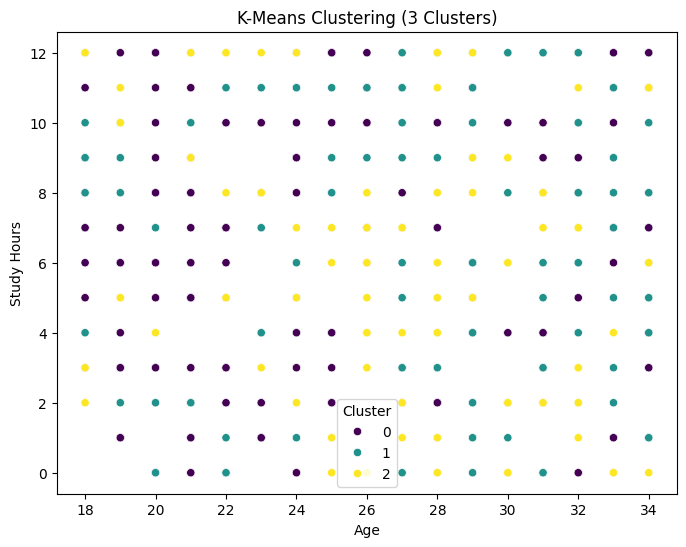

In [26]:
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled[numeric_cols])

df['Cluster'] = clusters

print("Hasil Klastering (3 Klaster)")
print(df.groupby('Cluster')[numeric_cols].mean())

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Age', y='Study Hours', hue='Cluster', palette='viridis')
plt.title("K-Means Clustering (3 Clusters)")
plt.savefig('cluster_result.png')
plt.show()
